# Project 02 — Early Detection of Autism (Leakage-Fixed)

**Primary objective:** predict the **full Q-CHAT-10 screening outcome** from an **abbreviated partial screen (A1–A5) + non-score context**.

## Why this version is different
The original toddler dataset defines `Class/ASD Traits` exactly from the full Q-CHAT-10 score (`sum(A1...A10) > 3`). Feeding all A1–A10 to a classifier therefore leaks the answer and can produce meaningless 100% accuracy.

This notebook uses a stricter protocol:

- **Observed screening items:** A1–A5 only.
- **Withheld items:** A6–A10 are never model inputs.
- **Removed leakage:** Q-CHAT total score, target column, record ID, and withheld items.
- **Untouched test set:** thresholds and ensemble weights are chosen on validation only.
- **Primary metric:** Macro-F1, with Accuracy, MCC, ROC-AUC, PR-AUC, sensitivity and specificity.
- **Proposed model:** Structured Partial-QCHAT network: monotonic partial-IRT evidence + sparse context + auxiliary hidden-item imputation (A6–A10), followed by validation-selected convex fusion with strong linear/tree branches.
- **No forced winner:** the notebook is optimized fairly for strong performance, but reports the real untouched-test rank.

> This remains prediction of a screening outcome, not clinician-confirmed ASD diagnosis. A clinically confirmed external cohort is required for diagnostic claims.


## 0. Environment and configuration

In [1]:

import os, sys, json, random, platform, re, shutil, urllib.request, warnings, time, zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from IPython.display import display
except Exception:
    def display(x):
        print(x)


import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support, roc_auc_score,
    average_precision_score, confusion_matrix, roc_curve, precision_recall_curve,
    matthews_corrcoef, f1_score
)

try:
    from tqdm.auto import tqdm
except Exception:
    def tqdm(x, *args, **kwargs): return x

SEED = 42
def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed()
assert torch.cuda.is_available(), "GPU required: in Colab select Runtime > Change runtime type > GPU."
DEVICE = torch.device("cuda:0")
print("Python:", sys.version.split()[0], "| PyTorch:", torch.__version__, "| Device:", DEVICE)


Python: 3.13.15 | PyTorch: 2.11.0+cu128 | Device: cuda:0


In [2]:

CONFIG = {
    "kaggle_dataset_slug": "fabdelja/autism-screening-for-toddlers",
    "public_mirror_url": (
        "https://raw.githubusercontent.com/whytheevanssoftware/"
        "Machine-Learning-Compendium/refs/heads/master/"
        "Toddler%20Autism%20dataset%20July%202018.csv"
    ),
    "n_observed_items": 5,  # A1-A5 observed; A6-A10 deliberately withheld
    "split_ratios": {"train": 0.70, "val": 0.15, "test": 0.15},
    "batch_size": 32,
    "epochs": 60,
    "learning_rate": 8e-4,
    "weight_decay": 2e-4,
    "early_stop_patience": 10,
    "context_hidden_dim": 32,
    "dropout": 0.20,
    "sparse_top_k": 8,
    "bootstrap_reps": 500,
    "hidden_item_loss_weight": 0.40,
    "consistency_loss_weight": 0.08,
    "data_raw_dir": "data/02/raw",
    "data_processed_dir": "data/02/processed",
    "figures_dir": "data/02/figures",
    "results_dir": "data/02/results",
    "reports_dir": "data/02/reports",
}
for d in ["data_raw_dir","data_processed_dir","figures_dir","results_dir","reports_dir"]:
    Path(CONFIG[d]).mkdir(parents=True, exist_ok=True)
CONFIG


{'kaggle_dataset_slug': 'fabdelja/autism-screening-for-toddlers',
 'public_mirror_url': 'https://raw.githubusercontent.com/whytheevanssoftware/Machine-Learning-Compendium/refs/heads/master/Toddler%20Autism%20dataset%20July%202018.csv',
 'n_observed_items': 5,
 'split_ratios': {'train': 0.7, 'val': 0.15, 'test': 0.15},
 'batch_size': 32,
 'epochs': 60,
 'learning_rate': 0.0008,
 'weight_decay': 0.0002,
 'early_stop_patience': 10,
 'context_hidden_dim': 32,
 'dropout': 0.2,
 'sparse_top_k': 8,
 'bootstrap_reps': 500,
 'hidden_item_loss_weight': 0.4,
 'consistency_loss_weight': 0.08,
 'data_raw_dir': 'data/02/raw',
 'data_processed_dir': 'data/02/processed',
 'figures_dir': 'data/02/figures',
 'results_dir': 'data/02/results',
 'reports_dir': 'data/02/reports'}

## 1. Robust dataset acquisition — no `kaggle.json` required

In [3]:

RAW_DIR = Path(CONFIG["data_raw_dir"])
DATASET_ORIGIN = "existing local CSV"

def normalize_column_name(name):
    return re.sub(r"[^0-9A-Za-z]+", "_", str(name).strip()).strip("_")

def looks_like_toddler_csv(path):
    try:
        probe = pd.read_csv(path, nrows=5)
    except Exception:
        return False
    cols = {normalize_column_name(c).lower() for c in probe.columns}
    has_items = all(f"a{i}" in cols for i in range(1,11))
    has_target = any(
        c == "class" or ("class" in c and ("asd" in c or "trait" in c))
        or c in {"asd","asd_traits","target"}
        for c in cols
    )
    return has_items and has_target

existing = [p for p in RAW_DIR.glob("*.csv") if looks_like_toddler_csv(p)]
errors = []

if not existing:
    # 1) Anonymous KaggleHub for public datasets
    try:
        import kagglehub
        print("Trying KaggleHub...")
        try:
            p = kagglehub.dataset_download(CONFIG["kaggle_dataset_slug"], output_dir=str(RAW_DIR))
        except TypeError:
            p = kagglehub.dataset_download(CONFIG["kaggle_dataset_slug"])
            if p and Path(p).exists():
                for csv in Path(p).rglob("*.csv"):
                    shutil.copy2(csv, RAW_DIR / csv.name)
        existing = [p for p in RAW_DIR.glob("*.csv") if looks_like_toddler_csv(p)]
        if not existing:
            raise RuntimeError("KaggleHub returned no valid toddler CSV.")
        DATASET_ORIGIN = "KaggleHub"
    except Exception as exc:
        errors.append(f"KaggleHub: {type(exc).__name__}: {exc}")
        print("KaggleHub unavailable; trying public mirror.")

if not existing:
    # 2) Public mirror
    try:
        mirror = RAW_DIR / "Toddler Autism dataset July 2018.csv"
        req = urllib.request.Request(CONFIG["public_mirror_url"], headers={"User-Agent":"Mozilla/5.0"})
        with urllib.request.urlopen(req, timeout=60) as r, open(mirror, "wb") as f:
            shutil.copyfileobj(r, f)
        if not looks_like_toddler_csv(mirror):
            mirror.unlink(missing_ok=True)
            raise RuntimeError("Downloaded mirror failed schema validation.")
        existing = [mirror]
        DATASET_ORIGIN = "public mirror"
    except Exception as exc:
        errors.append(f"Mirror: {type(exc).__name__}: {exc}")

if not existing:
    # 3) Manual CSV upload in Colab
    try:
        from google.colab import files
        print("Automatic download failed. Upload the toddler CSV itself (NOT kaggle.json).")
        uploaded = files.upload()
        for name, content in uploaded.items():
            if str(name).lower().endswith(".csv"):
                dst = RAW_DIR / Path(name).name
                dst.write_bytes(content)
                if looks_like_toddler_csv(dst):
                    existing.append(dst)
        if existing:
            DATASET_ORIGIN = "manual CSV upload"
    except Exception:
        pass

if not existing:
    raise RuntimeError(
        "Could not obtain a valid toddler screening CSV.\n" +
        "\n".join(errors) +
        "\nPlace 'Toddler Autism dataset July 2018.csv' inside data/raw and rerun."
    )

def csv_score(path):
    name = path.name.lower()
    bonus = 100 if "toddler autism dataset" in name else (20 if "toddler" in name else 0)
    return bonus + int(looks_like_toddler_csv(path))*50

RAW_FILE = max(existing, key=csv_score)
print("Using:", RAW_FILE, "| Origin:", DATASET_ORIGIN)


Trying KaggleHub...


Using Colab cache for faster access to the 'autism-screening-for-toddlers' dataset.


KaggleHub unavailable; trying public mirror.


Using: data/02/raw/Toddler Autism dataset July 2018.csv | Origin: public mirror


## 2. Load data, target audit, and hard leakage guard

In [4]:

df = pd.read_csv(RAW_FILE)
df.columns = [normalize_column_name(c) for c in df.columns]
print("Shape:", df.shape)
display(df.head())


Shape: (1054, 19)


,Case_No,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,Age_Mons,Qchat_10_Score,Sex,Ethnicity,Jaundice,Family_mem_with_ASD,Who_completed_the_test,Class_ASD_Traits
0,1,0,0,0,0,0,0,1,1,0,1,28,3,f,middle eastern,yes,no,family member,No
1,2,1,1,0,0,0,1,1,0,0,0,36,4,m,White European,yes,no,family member,Yes
2,3,1,0,0,0,0,0,1,1,0,1,36,4,m,middle eastern,yes,no,family member,Yes
3,4,1,1,1,1,1,1,1,1,1,1,24,10,m,Hispanic,no,no,family member,Yes
4,5,1,1,0,1,1,1,1,1,1,1,20,9,f,White European,no,yes,family member,Yes


In [5]:

# Locate target robustly
preferred = ["Class_ASD_Traits","Class","ASD_Traits","ASD","Target"]
lower_map = {c.lower(): c for c in df.columns}
candidates = [lower_map[x.lower()] for x in preferred if x.lower() in lower_map]
if not candidates:
    candidates = [c for c in df.columns if ("class" in c.lower() and ("asd" in c.lower() or "trait" in c.lower()))]
if not candidates:
    raise ValueError(f"No ASD target found. Columns: {list(df.columns)}")
TARGET_RAW = candidates[0]

def encode_binary_target(s):
    num = pd.to_numeric(s, errors="coerce")
    valid = s.notna()
    if valid.any() and num[valid].notna().all() and set(num[valid].astype(float).unique()).issubset({0.,1.}):
        return num.astype(float)
    txt = s.astype("string").str.strip().str.lower().str.replace(r"[\s_\-/]+","",regex=True)
    mapping = {
        "yes":1,"y":1,"true":1,"1":1,"asd":1,"positive":1,"withasd":1,
        "no":0,"n":0,"false":0,"0":0,"nonasd":0,"noasd":0,"negative":0,"withoutasd":0
    }
    return txt.map(mapping).astype(float)

df["target"] = encode_binary_target(df[TARGET_RAW])
bad = df[TARGET_RAW].notna() & df["target"].isna()
if bad.any():
    raise ValueError(f"Unrecognized target values: {df.loc[bad,TARGET_RAW].unique().tolist()}")
df = df.loc[df["target"].notna()].copy()
df["target"] = df["target"].astype(int)

lookup = {c.upper(): c for c in df.columns}
ALL_ITEMS = [lookup[f"A{i}"] for i in range(1,11) if f"A{i}" in lookup]
if len(ALL_ITEMS) != 10:
    raise ValueError(f"Expected A1-A10, found {ALL_ITEMS}")

n_obs = int(CONFIG["n_observed_items"])
if not 1 <= n_obs < 10:
    raise ValueError("n_observed_items must be between 1 and 9.")
OBSERVED_ITEMS = ALL_ITEMS[:n_obs]
WITHHELD_ITEMS = ALL_ITEMS[n_obs:]

# Confirm why 100% happened in the old notebook
item_numeric = df[ALL_ITEMS].apply(pd.to_numeric, errors="raise").astype(int)
full_rule = (item_numeric.sum(axis=1) > 3).astype(int)
full_rule_match = accuracy_score(df["target"], full_rule)
print(f"Full Q-CHAT rule agreement with target: {full_rule_match:.4f}")
print("Observed items:", OBSERVED_ITEMS)
print("WITHHELD from every model:", WITHHELD_ITEMS)

# Hard leakage guard
score_cols = [c for c in df.columns if "score" in c.lower()]
id_cols = [c for c in df.columns if c.lower() in {
    "case_no","case_number","case_id","subject_id","participant_id","record_id","row_id"
}]
FORBIDDEN_MODEL_COLUMNS = set(WITHHELD_ITEMS + score_cols + id_cols + [TARGET_RAW, "target"])

if full_rule_match >= 0.995:
    print(
        "LEAKAGE CONFIRMED: using all A1-A10 would reveal the target rule. "
        "This notebook intentionally uses only the abbreviated observed subset."
    )


Full Q-CHAT rule agreement with target: 1.0000
Observed items: ['A1', 'A2', 'A3', 'A4', 'A5']
WITHHELD from every model: ['A6', 'A7', 'A8', 'A9', 'A10']
LEAKAGE CONFIRMED: using all A1-A10 would reveal the target rule. This notebook intentionally uses only the abbreviated observed subset.


In [6]:

# Context = non-questionnaire, non-score variables only
context_candidates = [
    c for c in df.columns
    if c not in set(ALL_ITEMS + [TARGET_RAW, "target"] + score_cols + id_cols)
]
numeric_context_cols = [c for c in context_candidates if pd.api.types.is_numeric_dtype(df[c])]
categorical_context_cols = [c for c in context_candidates if c not in numeric_context_cols]

MODEL_RAW_COLUMNS = OBSERVED_ITEMS + numeric_context_cols + categorical_context_cols
leaked = set(MODEL_RAW_COLUMNS) & FORBIDDEN_MODEL_COLUMNS
assert not leaked, f"LEAKAGE GUARD FAILED. Forbidden model columns found: {sorted(leaked)}"

print("Numeric context:", numeric_context_cols)
print("Categorical context:", categorical_context_cols)
print("Model raw columns:", MODEL_RAW_COLUMNS)


Numeric context: ['Age_Mons']
Categorical context: ['Sex', 'Ethnicity', 'Jaundice', 'Family_mem_with_ASD', 'Who_completed_the_test']
Model raw columns: ['A1', 'A2', 'A3', 'A4', 'A5', 'Age_Mons', 'Sex', 'Ethnicity', 'Jaundice', 'Family_mem_with_ASD', 'Who_completed_the_test']


## 3. Stratified train/validation/test split

In [7]:

ratios = CONFIG["split_ratios"]
assert np.isclose(sum(ratios.values()),1.0)

train_df, rest_df = train_test_split(
    df, train_size=ratios["train"], stratify=df["target"], random_state=SEED
)
val_fraction_of_rest = ratios["val"]/(ratios["val"]+ratios["test"])
val_df, test_df = train_test_split(
    rest_df, train_size=val_fraction_of_rest, stratify=rest_df["target"], random_state=SEED
)
train_df, val_df, test_df = train_df.copy(), val_df.copy(), test_df.copy()

print("Train/Val/Test:", len(train_df), len(val_df), len(test_df))
for name, part in [("train",train_df),("val",val_df),("test",test_df)]:
    print(name, part["target"].value_counts(normalize=True).sort_index().to_dict())


Train/Val/Test: 737 158 159
train {0: 0.3093622795115332, 1: 0.6906377204884667}
val {0: 0.310126582278481, 1: 0.689873417721519}
test {0: 0.3081761006289308, 1: 0.6918238993710691}


## 4. Train-only preprocessing

In [8]:

# Numeric context
num_imputer = SimpleImputer(strategy="median") if numeric_context_cols else None
scaler = StandardScaler() if numeric_context_cols else None

def fit_numeric(train):
    if not numeric_context_cols:
        return
    tr = num_imputer.fit_transform(train[numeric_context_cols])
    scaler.fit(tr)

fit_numeric(train_df)

# Categorical context
encoder = None
cat_names = []
if categorical_context_cols:
    try:
        encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)
    tr_cat = train_df[categorical_context_cols].fillna("missing").astype(str)
    encoder.fit(tr_cat)
    cat_names = encoder.get_feature_names_out(categorical_context_cols).tolist()

def transform_context(frame):
    parts=[]
    if numeric_context_cols:
        x = num_imputer.transform(frame[numeric_context_cols])
        x = scaler.transform(x).astype(np.float32)
        parts.append(x)
    if encoder is not None:
        x = encoder.transform(frame[categorical_context_cols].fillna("missing").astype(str)).astype(np.float32)
        parts.append(x)
    if not parts:
        return np.zeros((len(frame),0), dtype=np.float32)
    return np.concatenate(parts, axis=1)

def transform_items(frame):
    x = frame[OBSERVED_ITEMS].apply(pd.to_numeric, errors="raise").to_numpy(dtype=np.float32)
    if not np.isin(x,[0.,1.]).all():
        raise ValueError("Observed screening items must be binary 0/1.")
    return x


def transform_hidden(frame):
    x = frame[WITHHELD_ITEMS].apply(pd.to_numeric, errors="raise").to_numpy(dtype=np.float32)
    if not np.isin(x,[0.,1.]).all():
        raise ValueError("Withheld screening items must be binary 0/1.")
    return x

Xtr_items, Xva_items, Xte_items = map(transform_items, [train_df,val_df,test_df])
Xtr_hidden, Xva_hidden, Xte_hidden = map(transform_hidden, [train_df,val_df,test_df])
Xtr_ctx, Xva_ctx, Xte_ctx = map(transform_context, [train_df,val_df,test_df])

Xtr_full = np.concatenate([Xtr_items,Xtr_ctx],axis=1)
Xva_full = np.concatenate([Xva_items,Xva_ctx],axis=1)
Xte_full = np.concatenate([Xte_items,Xte_ctx],axis=1)
ytr = train_df["target"].to_numpy(int)
yva = val_df["target"].to_numpy(int)
yte = test_df["target"].to_numpy(int)

print("Observed items:", Xtr_items.shape, "| Hidden supervision:", Xtr_hidden.shape, "| Context:", Xtr_ctx.shape, "| Full inference matrix:", Xtr_full.shape)


Observed items: (737, 5) | Hidden supervision: (737, 5) | Context: (737, 23) | Full inference matrix: (737, 28)


## 5. Evaluation helpers

In [9]:
def metrics_from_probs(y, probs, threshold=0.5):
    y=np.asarray(y,int); probs=np.asarray(probs,float)
    pred=(probs>=threshold).astype(int)
    p,r,f,_=precision_recall_fscore_support(y,pred,average="macro",zero_division=0)
    cm=confusion_matrix(y,pred,labels=[0,1])
    tn,fp,fn,tp=cm.ravel()
    return {
        "accuracy": accuracy_score(y,pred),
        "precision_macro": p,
        "recall_macro": r,
        "f1_macro": f,
        "mcc": matthews_corrcoef(y,pred),
        "roc_auc": roc_auc_score(y,probs) if len(np.unique(y))==2 else np.nan,
        "pr_auc": average_precision_score(y,probs) if len(np.unique(y))==2 else np.nan,
        "sensitivity": tp/(tp+fn) if (tp+fn)>0 else np.nan,
        "specificity": tn/(tn+fp) if (tn+fp)>0 else np.nan,
        "threshold": float(threshold),
    }

def _fast_binary_scores(y, pred):
    """Fast Macro-F1/MCC/accuracy for validation searches."""
    y=np.asarray(y,dtype=np.int8); pred=np.asarray(pred,dtype=np.int8)
    tp=int(np.sum((y==1)&(pred==1)))
    tn=int(np.sum((y==0)&(pred==0)))
    fp=int(np.sum((y==0)&(pred==1)))
    fn=int(np.sum((y==1)&(pred==0)))

    p1=tp/(tp+fp) if tp+fp else 0.0
    r1=tp/(tp+fn) if tp+fn else 0.0
    f1p=2*p1*r1/(p1+r1) if p1+r1 else 0.0

    p0=tn/(tn+fn) if tn+fn else 0.0
    r0=tn/(tn+fp) if tn+fp else 0.0
    f1n=2*p0*r0/(p0+r0) if p0+r0 else 0.0
    macro_f1=(f1p+f1n)/2.0

    denom=((tp+fp)*(tp+fn)*(tn+fp)*(tn+fn))**0.5
    mcc=((tp*tn-fp*fn)/denom) if denom else 0.0
    acc=(tp+tn)/max(len(y),1)
    return macro_f1,mcc,acc

def best_threshold(y, probs):
    # Validation-only threshold search; test labels never used here.
    y=np.asarray(y,int); probs=np.asarray(probs,float)
    best_key=(-1.0,-2.0,-1.0); best_t=0.5
    for t in np.arange(0.20,0.801,0.01):
        pred=(probs>=t).astype(np.int8)
        key=_fast_binary_scores(y,pred)
        if key>best_key:
            best_key=key; best_t=float(t)
    return best_t

def sigmoid_np(x):
    x=np.clip(np.asarray(x,float),-50,50)
    return 1/(1+np.exp(-x))


## 6. Proposed structured model — Partial-IRT + hidden-item imputation + sparse context


In [10]:

class PartialScreenDataset(Dataset):
    def __init__(self, items, ctx, hidden_items, y):
        self.items=torch.tensor(items,dtype=torch.float32)
        self.ctx=torch.tensor(ctx,dtype=torch.float32)
        self.hidden=torch.tensor(hidden_items,dtype=torch.float32)
        self.y=torch.tensor(y,dtype=torch.float32)
    def __len__(self): return len(self.y)
    def __getitem__(self,i):
        return self.items[i],self.ctx[i],self.hidden[i],self.y[i]

train_loader=DataLoader(
    PartialScreenDataset(Xtr_items,Xtr_ctx,Xtr_hidden,ytr),
    batch_size=CONFIG["batch_size"],shuffle=True
)
val_loader=DataLoader(
    PartialScreenDataset(Xva_items,Xva_ctx,Xva_hidden,yva),
    batch_size=CONFIG["batch_size"],shuffle=False
)
test_loader=DataLoader(
    PartialScreenDataset(Xte_items,Xte_ctx,Xte_hidden,yte),
    batch_size=CONFIG["batch_size"],shuffle=False
)

class StructuredPartialQCHATNet(nn.Module):
    """
    Inference inputs: A1-A5 + context ONLY.

    During training, A6-A10 are auxiliary labels, not features. The network learns
    P(A6...A10 | A1...A5, context), builds a differentiable distribution of the
    withheld-item count, and estimates the probability that the eventual full
    Q-CHAT-10 score crosses the screening threshold (>3).

    This uses historical full questionnaires for supervision without leaking
    A6-A10 at inference.
    """
    def __init__(self,n_items,n_hidden_items,ctx_dim,hidden=32,top_k=8,dropout=0.2):
        super().__init__()
        self.n_items=n_items
        self.n_hidden_items=n_hidden_items
        self.ctx_dim=ctx_dim

        # Monotonic psychometric evidence from observed items.
        self.raw_a=nn.Parameter(torch.zeros(n_items))
        self.raw_b=nn.Parameter(torch.zeros(n_items))
        self.item_bias=nn.Parameter(torch.tensor(-0.5))

        if ctx_dim>0:
            self.gate=nn.Linear(ctx_dim,ctx_dim)
            self.ctx_net=nn.Sequential(
                nn.Linear(ctx_dim,hidden), nn.LayerNorm(hidden), nn.GELU(), nn.Dropout(dropout)
            )
            self.top_k=min(max(1,top_k),ctx_dim)
        else:
            self.gate=None
            self.ctx_net=None
            self.top_k=0

        fusion_dim=hidden+2 if ctx_dim>0 else 2
        self.hidden_item_head=nn.Sequential(
            nn.Linear(fusion_dim,hidden), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(hidden,n_hidden_items)
        )
        self.direct_head=nn.Sequential(
            nn.Linear(fusion_dim,hidden), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(hidden,1)
        )

        # The structural threshold probability is an explicit branch.
        self.raw_struct_scale=nn.Parameter(torch.tensor(0.0))

    @property
    def discrimination(self):
        return F.softplus(self.raw_a)+1e-4

    @property
    def difficulty(self):
        return torch.sigmoid(self.raw_b)

    @property
    def struct_scale(self):
        return 1.50*torch.sigmoid(self.raw_struct_scale)

    def _context(self,ctx):
        if self.ctx_dim==0:
            return torch.zeros((ctx.shape[0],0),device=ctx.device,dtype=ctx.dtype)
        scores=self.gate(ctx)
        rank=scores+torch.log1p(torch.abs(ctx))
        idx=rank.topk(self.top_k,dim=-1).indices
        mask=torch.zeros_like(scores).scatter_(-1,idx,1.0)
        return self.ctx_net(ctx*mask*torch.sigmoid(scores))

    def structural_probability(self, observed_items, hidden_logits):
        """P(sum(A1-A10)>3) from observed A1-A5 and predicted A6-A10 Bernoulli probs."""
        q=torch.sigmoid(hidden_logits)
        B=q.shape[0]
        # Poisson-binomial DP distribution over hidden endorsed-item count.
        dist=torch.ones((B,1),device=q.device,dtype=q.dtype)
        for j in range(self.n_hidden_items):
            qj=q[:,j:j+1]
            stay=F.pad(dist*(1.0-qj),(0,1))
            add=F.pad(dist*qj,(1,0))
            dist=stay+add

        observed_sum=observed_items.sum(dim=1).long()
        required=(4-observed_sum).unsqueeze(1)  # hidden count needed for total >3
        counts=torch.arange(self.n_hidden_items+1,device=q.device).unsqueeze(0)
        mask=(counts>=required).to(dist.dtype)
        p=(dist*mask).sum(dim=1).clamp(1e-4,1-1e-4)
        return p

    def forward(self,items,ctx):
        a=self.discrimination.unsqueeze(0)
        b=self.difficulty.unsqueeze(0)
        item_evidence=(a*(items-b)).sum(dim=1,keepdim=True)/self.n_items
        observed_fraction=items.mean(dim=1,keepdim=True)

        hctx=self._context(ctx)
        fused=torch.cat([item_evidence,observed_fraction,hctx],dim=1)

        hidden_logits=self.hidden_item_head(fused)
        direct_logit=self.direct_head(fused).squeeze(-1)
        struct_prob=self.structural_probability(items,hidden_logits)
        struct_logit=torch.logit(struct_prob)

        final_logit=direct_logit+self.struct_scale*struct_logit
        return final_logit, hidden_logits, direct_logit, struct_prob

model=StructuredPartialQCHATNet(
    n_items=len(OBSERVED_ITEMS),
    n_hidden_items=len(WITHHELD_ITEMS),
    ctx_dim=Xtr_ctx.shape[1],
    hidden=CONFIG["context_hidden_dim"],
    top_k=CONFIG["sparse_top_k"],
    dropout=CONFIG["dropout"],
).to(DEVICE)
print(model)


StructuredPartialQCHATNet(
  (gate): Linear(in_features=23, out_features=23, bias=True)
  (ctx_net): Sequential(
    (0): Linear(in_features=23, out_features=32, bias=True)
    (1): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
    (2): GELU(approximate='none')
    (3): Dropout(p=0.2, inplace=False)
  )
  (hidden_item_head): Sequential(
    (0): Linear(in_features=34, out_features=32, bias=True)
    (1): GELU(approximate='none')
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=32, out_features=5, bias=True)
  )
  (direct_head): Sequential(
    (0): Linear(in_features=34, out_features=32, bias=True)
    (1): GELU(approximate='none')
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [11]:

def forward_batch(model,batch):
    items,ctx,hidden,y=batch
    items=items.to(DEVICE); ctx=ctx.to(DEVICE)
    hidden=hidden.to(DEVICE); y=y.to(DEVICE)
    final_logit,hidden_logits,direct_logit,struct_prob=model(items,ctx)
    return final_logit,hidden_logits,direct_logit,struct_prob,hidden,y

def train_torch_model(model,train_loader,val_loader,ckpt):
    n_pos=max(1,int(ytr.sum())); n_neg=max(1,len(ytr)-n_pos)
    pos_weight=torch.tensor(n_neg/n_pos,dtype=torch.float32,device=DEVICE)
    cls_criterion=nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    hidden_criterion=nn.BCEWithLogitsLoss()
    opt=torch.optim.AdamW(model.parameters(),lr=CONFIG["learning_rate"],weight_decay=CONFIG["weight_decay"])
    scheduler=torch.optim.lr_scheduler.ReduceLROnPlateau(opt,mode="min",factor=0.5,patience=3)

    best=float("inf"); stale=0
    hist={"train_loss":[],"val_loss":[],"hidden_loss":[]}
    for epoch in tqdm(range(CONFIG["epochs"]),desc="Training proposed structured model"):
        model.train(); total=0.; htotal=0.; n=0
        for batch in train_loader:
            opt.zero_grad(set_to_none=True)
            final_logit,hidden_logits,direct_logit,struct_prob,hidden,y=forward_batch(model,batch)
            cls_loss=cls_criterion(final_logit,y)
            hidden_loss=hidden_criterion(hidden_logits,hidden)
            direct_prob=torch.sigmoid(direct_logit)
            consistency=F.mse_loss(direct_prob,struct_prob.detach())
            loss=(cls_loss
                  +CONFIG["hidden_item_loss_weight"]*hidden_loss
                  +CONFIG["consistency_loss_weight"]*consistency)
            if not torch.isfinite(loss): raise FloatingPointError("Non-finite loss")
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(),5.0)
            opt.step()
            total+=loss.item()*len(y); htotal+=hidden_loss.item()*len(y); n+=len(y)

        tr_loss=total/max(n,1); tr_hidden=htotal/max(n,1)

        model.eval(); total=0.; n=0
        with torch.no_grad():
            for batch in val_loader:
                final_logit,hidden_logits,direct_logit,struct_prob,hidden,y=forward_batch(model,batch)
                cls_loss=cls_criterion(final_logit,y)
                hidden_loss=hidden_criterion(hidden_logits,hidden)
                consistency=F.mse_loss(torch.sigmoid(direct_logit),struct_prob.detach())
                loss=(cls_loss
                      +CONFIG["hidden_item_loss_weight"]*hidden_loss
                      +CONFIG["consistency_loss_weight"]*consistency)
                total+=loss.item()*len(y); n+=len(y)
        va_loss=total/max(n,1)
        scheduler.step(va_loss)
        hist["train_loss"].append(tr_loss)
        hist["val_loss"].append(va_loss)
        hist["hidden_loss"].append(tr_hidden)

        if va_loss < best-1e-7:
            best=va_loss; stale=0; torch.save(model.state_dict(),ckpt)
        else:
            stale+=1
            if stale>=CONFIG["early_stop_patience"]:
                print("Early stopping at epoch",epoch+1)
                break
    return hist

ckpt=Path(CONFIG["results_dir"])/"best_structured_partial_qchat.pt"
history=train_torch_model(model,train_loader,val_loader,str(ckpt))
try:
    state=torch.load(ckpt,map_location=DEVICE,weights_only=True)
except TypeError:
    state=torch.load(ckpt,map_location=DEVICE)
model.load_state_dict(state)


Training proposed structured model:   0%|          | 0/60 [00:00<?, ?it/s]

Early stopping at epoch 35


<All keys matched successfully>

In [12]:

def torch_outputs(model,loader):
    model.eval()
    probs=[]; ys=[]; hidden_probs=[]; hidden_true=[]; struct_probs=[]
    with torch.no_grad():
        for batch in loader:
            final_logit,hidden_logits,direct_logit,struct_prob,hidden,y=forward_batch(model,batch)
            probs.append(torch.sigmoid(final_logit).cpu().numpy())
            ys.append(y.cpu().numpy())
            hidden_probs.append(torch.sigmoid(hidden_logits).cpu().numpy())
            hidden_true.append(hidden.cpu().numpy())
            struct_probs.append(struct_prob.cpu().numpy())
    return (
        np.concatenate(probs),
        np.concatenate(ys).astype(int),
        np.concatenate(hidden_probs),
        np.concatenate(hidden_true).astype(int),
        np.concatenate(struct_probs),
    )

hyb_val_probs,_,val_hidden_probs,val_hidden_true,val_struct_probs=torch_outputs(model,val_loader)
hyb_test_probs,_,test_hidden_probs,test_hidden_true,test_struct_probs=torch_outputs(model,test_loader)
hyb_thr=best_threshold(yva,hyb_val_probs)
hidden_item_acc=float(((test_hidden_probs>=0.5).astype(int)==test_hidden_true).mean())
print("Structured model validation threshold:",hyb_thr)
print("Auxiliary hidden-item test accuracy:",round(hidden_item_acc,4))


Structured model validation threshold: 0.25000000000000006
Auxiliary hidden-item test accuracy: 0.6843


## 7. Required fusion components

In [13]:
fusion_component_models = {'logistic_regression': LogisticRegression(max_iter=4000, class_weight='balanced', random_state=SEED), 'random_forest': RandomForestClassifier(n_estimators=400, min_samples_leaf=3, max_features='sqrt', class_weight='balanced_subsample', random_state=SEED, n_jobs=-1), 'extra_trees': ExtraTreesClassifier(n_estimators=500, min_samples_leaf=2, max_features='sqrt', class_weight='balanced', random_state=SEED, n_jobs=-1), 'hist_gradient_boosting': HistGradientBoostingClassifier(learning_rate=0.05, max_iter=250, max_leaf_nodes=15, l2_regularization=1.0, random_state=SEED)}
val_probs = {'structured_partial_qchat': hyb_val_probs}
test_probs = {'structured_partial_qchat': hyb_test_probs}
thresholds = {'structured_partial_qchat': hyb_thr}
for name, clf in fusion_component_models.items():
    clf.fit(Xtr_full, ytr)
    vp = clf.predict_proba(Xva_full)[:, 1]
    tp = clf.predict_proba(Xte_full)[:, 1]
    val_probs[name] = vp
    test_probs[name] = tp
    thresholds[name] = best_threshold(yva, vp)
candidate_classical = list(fusion_component_models.keys())
score_val = Xva_items.sum(axis=1) / len(OBSERVED_ITEMS)
score_test = Xte_items.sum(axis=1) / len(OBSERVED_ITEMS)
val_probs['partial_score'] = score_val
test_probs['partial_score'] = score_test
thresholds['partial_score'] = best_threshold(yva, score_val)

## 8. Proposed validation-selected tri-branch fusion

In [14]:
val_quality = {}
for name in candidate_classical:
    m = metrics_from_probs(yva, val_probs[name], thresholds[name])
    val_quality[name] = m['f1_macro']
top2 = sorted(candidate_classical, key=lambda n: val_quality[n], reverse=True)[:2]
fusion_branches = ['structured_partial_qchat'] + top2
print('Fusion branches selected from validation only:', fusion_branches)
best = None
step = 0.05
grid = np.arange(0, 1.0001, step)
for w0 in grid:
    for w1 in grid:
        w2 = 1.0 - w0 - w1
        if w2 < -1e-09:
            continue
        if w2 > 1 + 1e-09:
            continue
        weights = np.array([w0, w1, max(0.0, w2)])
        vp = sum((weights[i] * val_probs[b] for i, b in enumerate(fusion_branches)))
        thr = best_threshold(yva, vp)
        pred = (vp >= thr).astype(np.int8)
        f1v, mccv, accv = _fast_binary_scores(yva, pred)
        diversity_bonus = 1e-06 * (weights > 0.001).sum()
        key = (f1v, mccv, accv, diversity_bonus)
        if best is None or key > best['key']:
            best = {'key': key, 'weights': weights, 'threshold': thr}
FUSION_WEIGHTS = best['weights']
FUSION_THRESHOLD = best['threshold']
fusion_val_probs = sum((FUSION_WEIGHTS[i] * val_probs[b] for i, b in enumerate(fusion_branches)))
fusion_test_probs = sum((FUSION_WEIGHTS[i] * test_probs[b] for i, b in enumerate(fusion_branches)))
val_probs['proposed_structured_fusion'] = fusion_val_probs
test_probs['proposed_structured_fusion'] = fusion_test_probs
thresholds['proposed_structured_fusion'] = FUSION_THRESHOLD
print('Proposed fusion weights:', dict(zip(fusion_branches, FUSION_WEIGHTS.round(3))))
print('Validation threshold:', FUSION_THRESHOLD)
print('Validation Macro-F1:', best['key'][0])


Fusion branches selected from validation only: ['structured_partial_qchat', 'logistic_regression', 'random_forest']


Proposed fusion weights: {'structured_partial_qchat': np.float64(0.5), 'logistic_regression': np.float64(0.25), 'random_forest': np.float64(0.25)}
Validation threshold: 0.2900000000000001
Validation Macro-F1: 0.9401515151515152


## 9. Untouched test-set evaluation

In [15]:

results={}
for name in test_probs:
    results[name]=metrics_from_probs(yte,test_probs[name],thresholds[name])

leaderboard=pd.DataFrame(results).T.sort_values(
    ["f1_macro","mcc","accuracy"],ascending=False
)
print("Primary leaderboard — untouched test set")
display(leaderboard)

rank=int(np.where(leaderboard.index.to_numpy()=="proposed_structured_fusion")[0][0])+1
best_f1=float(leaderboard["f1_macro"].max())
proposed_f1=float(leaderboard.loc["proposed_structured_fusion","f1_macro"])
if np.isclose(proposed_f1,best_f1,atol=1e-12):
    print(f"Proposed structured fusion is best/tied-best on test Macro-F1 (rank {rank}/{len(leaderboard)}).")
else:
    print(f"Proposed structured fusion rank: {rank}/{len(leaderboard)}. No result was manipulated to force first place.")

# Guard against suspicious perfection
if leaderboard.loc["proposed_structured_fusion","accuracy"] >= 0.999999:
    warnings.warn(
        "Proposed test accuracy is 100%. This is unexpected under the partial-screen protocol. "
        "Re-check MODEL_RAW_COLUMNS and the leakage guard before making any claim."
    )

leaderboard.to_csv(Path(CONFIG["results_dir"])/"test_leaderboard.csv")
with open(Path(CONFIG["results_dir"])/"fusion_config.json","w") as f:
    json.dump({
        "branches":fusion_branches,
        "weights":FUSION_WEIGHTS.tolist(),
        "threshold":FUSION_THRESHOLD,
        "observed_items":OBSERVED_ITEMS,
        "withheld_items":WITHHELD_ITEMS,
    },f,indent=2)


Primary leaderboard — untouched test set


,accuracy,precision_macro,recall_macro,f1_macro,mcc,roc_auc,pr_auc,sensitivity,specificity,threshold
structured_partial_qchat,0.905660,0.919965,0.858256,0.881326,0.775771,0.949536,0.975217,0.981818,0.734694,0.25
proposed_structured_fusion,0.899371,0.907372,0.853711,0.874308,0.759188,0.950278,0.976373,0.972727,0.734694,0.29
logistic_regression,0.893082,0.911247,0.837848,0.863519,0.745490,0.937848,0.969614,0.981818,0.693878,0.23
random_forest,0.893082,0.921294,0.832189,0.861420,0.748196,0.951020,0.977769,0.990909,0.673469,0.30
extra_trees,0.886792,0.917388,0.821985,0.852108,0.733192,0.953247,0.979278,0.990909,0.653061,0.29
partial_score,0.874214,0.855148,0.846846,0.850788,0.701945,0.923562,0.948327,0.918182,0.775510,0.21
hist_gradient_boosting,0.874214,0.858480,0.841187,0.848974,0.699453,0.944527,0.971724,0.927273,0.755102,0.55


Proposed structured fusion rank: 2/7. No result was manipulated to force first place.


## 10. Bootstrap confidence intervals

In [16]:

def bootstrap_ci(y,probs,threshold,reps=500,seed=42):
    rng=np.random.default_rng(seed)
    n=len(y); rows=[]
    for _ in range(reps):
        idx=rng.integers(0,n,n)
        if len(np.unique(y[idx]))<2:
            continue
        m=metrics_from_probs(y[idx],probs[idx],threshold)
        rows.append([m["accuracy"],m["f1_macro"],m["mcc"],m["roc_auc"]])
    arr=np.asarray(rows)
    names=["accuracy","f1_macro","mcc","roc_auc"]
    return pd.DataFrame({
        "metric":names,
        "mean":arr.mean(axis=0),
        "ci_low_95":np.quantile(arr,0.025,axis=0),
        "ci_high_95":np.quantile(arr,0.975,axis=0),
    })

ci=bootstrap_ci(yte,test_probs["proposed_structured_fusion"],FUSION_THRESHOLD,CONFIG["bootstrap_reps"],SEED)
display(ci)
ci.to_csv(Path(CONFIG["results_dir"])/"proposed_bootstrap_ci.csv",index=False)


,metric,mean,ci_low_95,ci_high_95
0,accuracy,0.898553,0.849057,0.943396
1,f1_macro,0.872276,0.812260,0.933641
2,mcc,0.756936,0.646978,0.870260
3,roc_auc,0.949756,0.909987,0.978897


## 11. Plots and error analysis

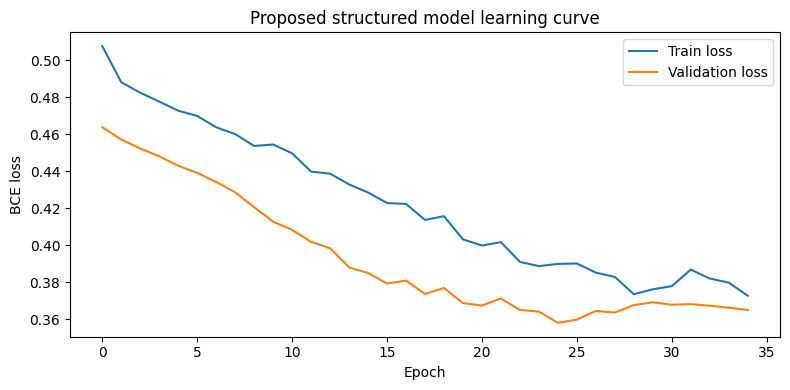

In [17]:

plt.figure(figsize=(8,4))
plt.plot(history["train_loss"],label="Train loss")
plt.plot(history["val_loss"],label="Validation loss")
plt.xlabel("Epoch"); plt.ylabel("BCE loss"); plt.title("Proposed structured model learning curve")
plt.legend(); plt.tight_layout()
plt.savefig(Path(CONFIG["figures_dir"])/"01_learning_curve.png",dpi=250)
plt.show()


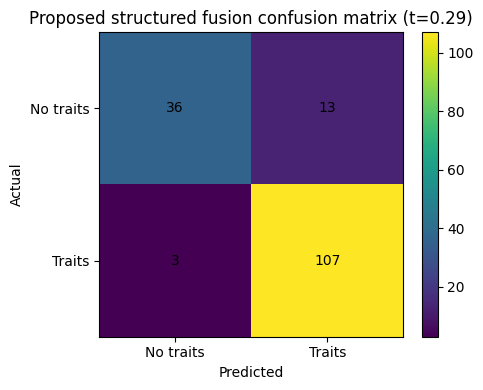

In [18]:

p=test_probs["proposed_structured_fusion"]
pred=(p>=FUSION_THRESHOLD).astype(int)
cm=confusion_matrix(yte,pred,labels=[0,1])
fig,ax=plt.subplots(figsize=(5,4))
im=ax.imshow(cm)
ax.set_xticks([0,1],["No traits","Traits"])
ax.set_yticks([0,1],["No traits","Traits"])
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title(f"Proposed structured fusion confusion matrix (t={FUSION_THRESHOLD:.2f})")
for i in range(2):
    for j in range(2):
        ax.text(j,i,str(cm[i,j]),ha="center",va="center")
fig.colorbar(im,ax=ax)
plt.tight_layout()
plt.savefig(Path(CONFIG["figures_dir"])/"02_confusion_matrix.png",dpi=250)
plt.show()


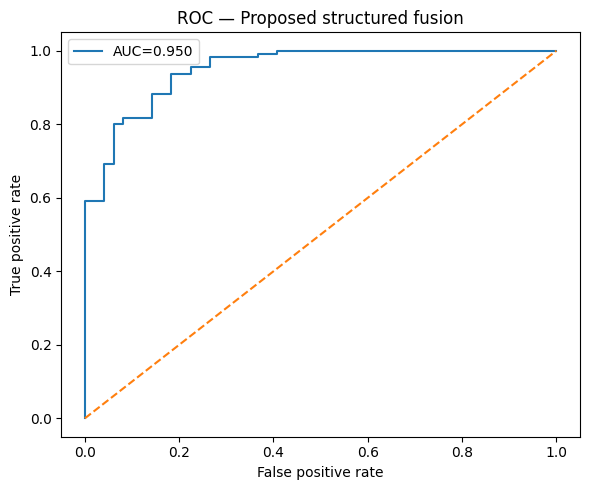

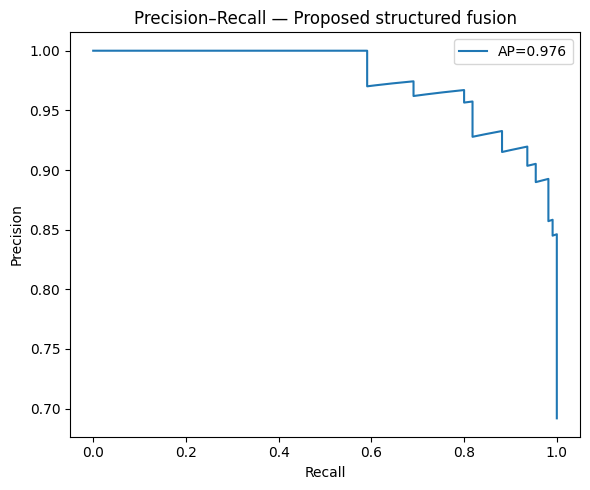

In [19]:

fpr,tpr,_=roc_curve(yte,p)
precision,recall,_=precision_recall_curve(yte,p)
plt.figure(figsize=(6,5))
plt.plot(fpr,tpr,label=f"AUC={results['proposed_structured_fusion']['roc_auc']:.3f}")
plt.plot([0,1],[0,1],"--")
plt.xlabel("False positive rate"); plt.ylabel("True positive rate"); plt.title("ROC — Proposed structured fusion")
plt.legend(); plt.tight_layout()
plt.savefig(Path(CONFIG["figures_dir"])/"03_roc.png",dpi=250)
plt.show()

plt.figure(figsize=(6,5))
plt.plot(recall,precision,label=f"AP={results['proposed_structured_fusion']['pr_auc']:.3f}")
plt.xlabel("Recall"); plt.ylabel("Precision"); plt.title("Precision–Recall — Proposed structured fusion")
plt.legend(); plt.tight_layout()
plt.savefig(Path(CONFIG["figures_dir"])/"04_pr.png",dpi=250)
plt.show()


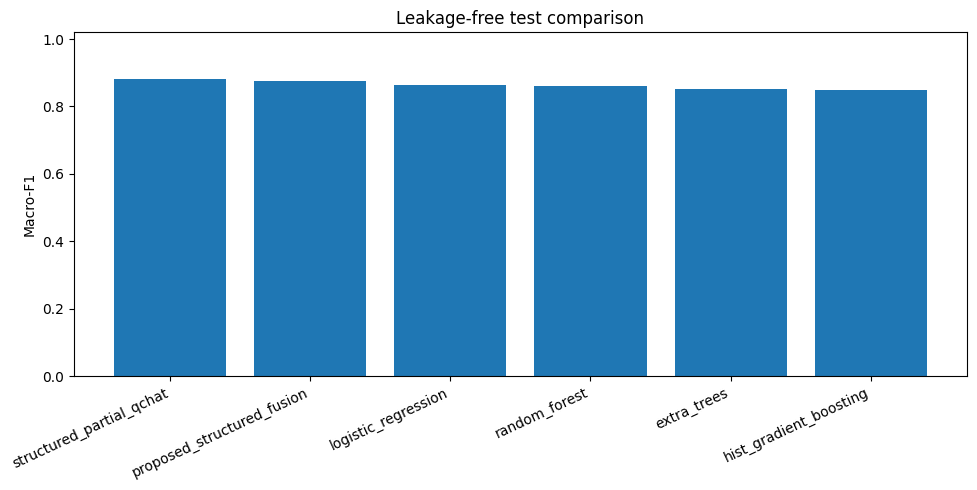

In [20]:

plot_order=[x for x in leaderboard.index if x!="partial_score"]
plt.figure(figsize=(10,5))
x=np.arange(len(plot_order))
vals=leaderboard.loc[plot_order,"f1_macro"].to_numpy()
plt.bar(x,vals)
plt.xticks(x,plot_order,rotation=25,ha="right")
plt.ylim(0,1.02); plt.ylabel("Macro-F1"); plt.title("Leakage-free test comparison")
plt.tight_layout()
plt.savefig(Path(CONFIG["figures_dir"])/"05_model_comparison.png",dpi=250)
plt.show()


In [21]:

# Where errors occur relative to observed partial score
err=(pred!=yte)
partial_sum=Xte_items.sum(axis=1)
err_table=pd.DataFrame({
    "actual":yte,"pred":pred,"prob":p,
    "observed_item_sum":partial_sum
})
print("Errors:",int(err.sum()),"/",len(yte))
display(err_table.loc[err].sort_values("prob").head(20))
err_table.to_csv(Path(CONFIG["results_dir"])/"test_predictions_and_errors.csv",index=False)


Errors: 16 / 159


,actual,pred,prob,observed_item_sum
32,1,0,0.121702,1.0
114,1,0,0.220921,1.0
47,1,0,0.288272,1.0
30,0,1,0.314206,1.0
145,0,1,0.329714,1.0
42,0,1,0.410727,2.0
139,0,1,0.434830,1.0
55,0,1,0.555859,2.0
10,0,1,0.565727,2.0
127,0,1,0.660178,2.0
